In [1]:
import pandas as pd
import numpy as np

In [ ]:
RUTA_CSV = "bicimad_2022_csv/trips_22_01.csv"   # ajusta a tu ruta

df_viajes = pd.read_csv(RUTA_CSV, sep=";")
print(f"Filas leídas: {len(df_viajes):,}")
df_viajes.head()

Filas leídas: 489,520


,fecha,idTrip,idBike,fleet,trip_minutes,geolocation_unlock,address_unlock,unlock_date,locktype,unlocktype,geolocation_lock,address_lock,lock_date,station_unlock,dock_unlock,unlock_station_name,station_lock,dock_lock,lock_station_name
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,489978239_1718_2022-01-01T00:18:37,1718.0,1.0,16.28,"{'type': 'Point', 'coordinates': [-3.6714166, ...",NaN,2022-01-01T00:02:20,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.688398, 4...",NaN,2022-01-01T00:18:37,200.0,3.0,Avenida de los Toreros,64.0,4.0,Plaza de la Independencia
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,06023769T_7340_2022-01-01T00:14:59,7340.0,1.0,7.10,"{'type': 'Point', 'coordinates': [-3.6894193, ...",NaN,2022-01-01T00:07:53,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6993465, ...",NaN,2022-01-01T00:14:59,69.0,5.0,Antonio Maura,169.0,17.0,Manuel Silvela
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(f"Antes: {len(df_viajes):,} filas")

df_viajes = df_viajes.dropna(how="all").reset_index(drop=True)

print(f"Después: {len(df_viajes):,} filas")

Antes: 489,520 filas
Después: 244,760 filas


In [4]:
print(f"Filas: {len(df_viajes):,}")
print(f"Columnas: {list(df_viajes.columns)}")
print(f"\nFilas completamente vacías: {df_viajes.isna().all(axis=1).sum():,}")
print(f"\nNulos por columna clave:")
for c in ["station_unlock", "station_lock", "unlock_date", "lock_date", "trip_minutes", "fleet"]:
    print(f"  {c:20s}: {df_viajes[c].isna().sum():,} ({df_viajes[c].isna().mean()*100:.2f}%)")
print(f"\ntrip_minutes describe:")
print(df_viajes["trip_minutes"].describe())

Filas: 244,760
Columnas: ['fecha', 'idTrip', 'idBike', 'fleet', 'trip_minutes', 'geolocation_unlock', 'address_unlock', 'unlock_date', 'locktype', 'unlocktype', 'geolocation_lock', 'address_lock', 'lock_date', 'station_unlock', 'dock_unlock', 'unlock_station_name', 'station_lock', 'dock_lock', 'lock_station_name']

Filas completamente vacías: 0

Nulos por columna clave:
  station_unlock      : 1,870 (0.76%)
  station_lock        : 2,307 (0.94%)
  unlock_date         : 0 (0.00%)
  lock_date           : 0 (0.00%)
  trip_minutes        : 0 (0.00%)
  fleet               : 0 (0.00%)

trip_minutes describe:
count    244760.000000
mean         30.955208
std         343.270265
min       -8677.330000
25%           5.180000
50%          10.350000
75%          16.130000
max       36027.350000
Name: trip_minutes, dtype: float64


Tenemos datos erroneos que vamos a quitar: tiempos negativos, tiempos demasiados elevados y tiempos muy cortos < 1 minuto que se devuelven cuando hay algun problema y no cuenta como viaje

In [5]:
len(df_viajes[(df_viajes["trip_minutes"] < 0)])

1604

Viajes que detectan un fallo en la bici

In [6]:
df_viajes_fallo = df_viajes[(df_viajes["trip_minutes"] < 1) & (df_viajes["trip_minutes"] > 0)]

In [7]:
df_viajes = df_viajes[(df_viajes["trip_minutes"] > 1) & (df_viajes["trip_minutes"] < 180)]
print(f"Filas: {len(df_viajes):,}")
print(f"Columnas: {list(df_viajes.columns)}")
print(f"\nFilas completamente vacías: {df_viajes.isna().all(axis=1).sum():,}")
print(f"\nNulos por columna clave:")
for c in ["station_unlock", "station_lock", "unlock_date", "lock_date", "trip_minutes", "fleet"]:
    print(f"  {c:20s}: {df_viajes[c].isna().sum():,} ({df_viajes[c].isna().mean()*100:.2f}%)")
print(f"\ntrip_minutes describe:")
print(df_viajes["trip_minutes"].describe())

Filas: 201,442
Columnas: ['fecha', 'idTrip', 'idBike', 'fleet', 'trip_minutes', 'geolocation_unlock', 'address_unlock', 'unlock_date', 'locktype', 'unlocktype', 'geolocation_lock', 'address_lock', 'lock_date', 'station_unlock', 'dock_unlock', 'unlock_station_name', 'station_lock', 'dock_lock', 'lock_station_name']

Filas completamente vacías: 0

Nulos por columna clave:
  station_unlock      : 1,528 (0.76%)
  station_lock        : 1,855 (0.92%)
  unlock_date         : 0 (0.00%)
  lock_date           : 0 (0.00%)
  trip_minutes        : 0 (0.00%)
  fleet               : 0 (0.00%)

trip_minutes describe:
count    201442.000000
mean         14.035395
std           9.307212
min           1.020000
25%           8.000000
50%          11.980000
75%          17.400000
max          59.980000
Name: trip_minutes, dtype: float64


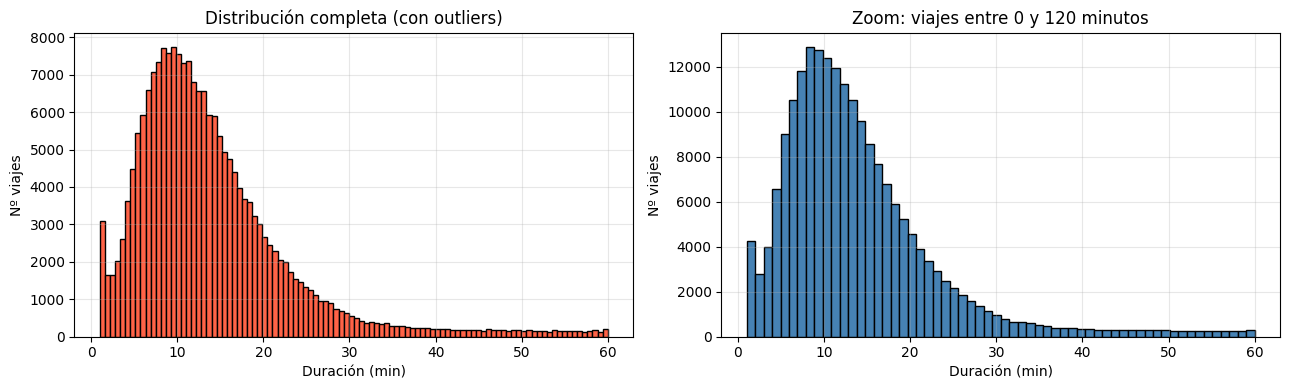

Viajes con duración < 0 minutos:     0
Viajes con duración > 120 minutos:   0
Viajes en rango razonable [0, 120]:  201,442


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Izquierda: distribución completa (la basura sale a la luz)
axes[0].hist(df_viajes["trip_minutes"], bins=100, color="tomato", edgecolor="black")
axes[0].set_title("Distribución completa (con outliers)")
axes[0].set_xlabel("Duración (min)")
axes[0].set_ylabel("Nº viajes")
axes[0].grid(alpha=0.3)

# Derecha: solo el rango razonable (0 a 120 min)
zona_normal = df_viajes[df_viajes["trip_minutes"].between(0, 120)]["trip_minutes"]
axes[1].hist(zona_normal, bins=60, color="steelblue", edgecolor="black")
axes[1].set_title("Zoom: viajes entre 0 y 120 minutos")
axes[1].set_xlabel("Duración (min)")
axes[1].set_ylabel("Nº viajes")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen de qué hay en cada extremo
print(f"Viajes con duración < 0 minutos:     {(df_viajes['trip_minutes'] < 0).sum():,}")
print(f"Viajes con duración > 120 minutos:   {(df_viajes['trip_minutes'] > 120).sum():,}")
print(f"Viajes en rango razonable [0, 120]:  {df_viajes['trip_minutes'].between(0, 120).sum():,}")

In [9]:
print(f"Antes: {len(df_viajes):,} filas")

# Solo descartar viajes sin estación ni de salida ni de llegada
mascara = ~(df_viajes["station_unlock"].isna() & df_viajes["station_lock"].isna())
df_viajes = df_viajes[mascara].reset_index(drop=True)

print(f"Después: {len(df_viajes):,} filas")
print(f"Eliminados: {(~mascara).sum():,} viajes 'totalmente libres'")

Antes: 201,442 filas
Después: 200,270 filas
Eliminados: 1,172 viajes 'totalmente libres'


In [10]:
print(df_viajes["trip_minutes"].describe())

count    200270.000000
mean         14.036089
std           9.276326
min           1.020000
25%           8.020000
50%          12.000000
75%          17.400000
max          59.980000
Name: trip_minutes, dtype: float64


Convertimos las fechas a datetime

In [11]:
print("Tipos ANTES:")
print(df_viajes[["unlock_date", "lock_date"]].dtypes)

df_viajes["unlock_date"] = pd.to_datetime(df_viajes["unlock_date"])
df_viajes["lock_date"]   = pd.to_datetime(df_viajes["lock_date"])

print("\nTipos DESPUÉS:")
print(df_viajes[["unlock_date", "lock_date"]].dtypes)
print(f"\nRango de unlock_date: {df_viajes['unlock_date'].min()}  ->  {df_viajes['unlock_date'].max()}")

Tipos ANTES:
unlock_date    object
lock_date      object
dtype: object

Tipos DESPUÉS:
unlock_date    datetime64[ns]
lock_date      datetime64[ns]
dtype: object

Rango de unlock_date: 2022-01-01 00:02:20  ->  2022-01-31 23:59:37


Redondeamos los viajes a la hora para facilitar al modelo

In [12]:
df_viajes["hora_unlock"] = df_viajes["unlock_date"].dt.floor("h")
df_viajes["hora_lock"]   = df_viajes["lock_date"].dt.floor("h")

# Comprobación rápida
df_viajes[["unlock_date", "hora_unlock", "lock_date", "hora_lock"]].head(5)

,unlock_date,hora_unlock,lock_date,hora_lock
0,2022-01-01 00:02:20,2022-01-01,2022-01-01 00:18:37,2022-01-01 00:00:00
1,2022-01-01 00:07:53,2022-01-01,2022-01-01 00:14:59,2022-01-01 00:00:00
2,2022-01-01 00:09:52,2022-01-01,2022-01-01 00:16:29,2022-01-01 00:00:00
3,2022-01-01 00:09:57,2022-01-01,2022-01-01 00:18:01,2022-01-01 00:00:00
4,2022-01-01 00:10:00,2022-01-01,2022-01-01 19:16:29,2022-01-01 19:00:00


In [13]:
# Mira el tipo y un ejemplo concreto a hora distinta de 00
print("Tipo de hora_unlock:", df_viajes["hora_unlock"].dtype)

# Coge una fila donde el unlock NO sea de madrugada (hora >= 10)
muestra = df_viajes[df_viajes["unlock_date"].dt.hour >= 10].head(3)
print("\nMuestra con horas más visibles:")
print(muestra[["unlock_date", "hora_unlock", "lock_date", "hora_lock"]])

# Y compara: las horas extraídas deben coincidir
print("\nComprobación: ¿la hora del original coincide con la del redondeado?")
print((df_viajes["unlock_date"].dt.hour == df_viajes["hora_unlock"].dt.hour).all())

Tipo de hora_unlock: datetime64[ns]

Muestra con horas más visibles:
             unlock_date         hora_unlock           lock_date  \
1067 2022-01-01 10:00:51 2022-01-01 10:00:00 2022-01-01 10:06:53   
1068 2022-01-01 10:02:26 2022-01-01 10:00:00 2022-01-01 10:24:02   
1069 2022-01-01 10:05:16 2022-01-01 10:00:00 2022-01-01 10:16:08   

               hora_lock  
1067 2022-01-01 10:00:00  
1068 2022-01-01 10:00:00  
1069 2022-01-01 10:00:00  

Comprobación: ¿la hora del original coincide con la del redondeado?
True


## Paso 3 · Agregar viajes a la rejilla estación-hora

En este paso transformamos los **viajes individuales** (un evento por fila: "fulanito cogió una bici en la estación Y a las Z:WW") en una **tabla de demanda por estación y hora**: "en la estación X, durante la hora Y, salieron N bicis y entraron M". Es el formato que necesita el modelo, ya que la ocupación que queremos predecir se calcula por estación y por franja horaria.

### Cómo lo hacemos

**1. Contamos las salidas.** Agrupamos por (`station_unlock`, `hora_unlock`) y contamos cuántos viajes hay en cada grupo. El resultado es una tabla con: estación de origen, hora de salida y número de bicis que salieron.

**2. Contamos las entradas.** Hacemos lo mismo pero con (`station_lock`, `hora_lock`). Renombramos las columnas a `id` y `hora` para que coincidan con la tabla de salidas.

**3. Unimos ambas tablas.** Con un `merge` con `how="outer"` para no perder ninguna combinación estación-hora: si una estación tuvo entradas pero no salidas (o al revés), igualmente aparece en el resultado.

**4. Rellenamos huecos con 0.** Los NaN generados por el merge no son "dato faltante", significan "no hubo movimientos", así que se convierten a 0. Pasamos las columnas a entero porque son conteos de viajes.

### Detalle importante

Cada viaje genera **dos eventos independientes**: una salida en su estación de origen (a la hora `unlock`) y una entrada en su estación de destino (a la hora `lock`). No se cuenta como un único evento, sino que afecta a **dos celdas distintas** de la tabla resultante. Esto es lo que permite que el modelo entienda los flujos reales entre estaciones.

### Resultado

Pasamos de **200.270 viajes sueltos** a una tabla compacta con cuatro columnas: `id`, `hora`, `salidas`, `entradas`. Cada fila representa una combinación única de estación y franja horaria con su balance de movimientos. Las horas sin actividad no aparecen todavía como filas; se rellenarán cuando unamos esta tabla con la del estado de las estaciones.

In [14]:
# 1) Salidas: agrupar por estación de origen y hora de salida
salidas = (df_viajes
           .groupby(["station_unlock", "hora_unlock"])
           .size()
           .reset_index(name="salidas")
           .rename(columns={"station_unlock": "id", "hora_unlock": "hora"}))

# 2) Entradas: agrupar por estación de destino y hora de llegada
entradas = (df_viajes
            .groupby(["station_lock", "hora_lock"])
            .size()
            .reset_index(name="entradas")
            .rename(columns={"station_lock": "id", "hora_lock": "hora"}))

# 3) Unir salidas y entradas en una sola tabla
df_demanda = pd.merge(salidas, entradas, on=["id", "hora"], how="outer")

# Las celdas donde no hubo nada (NaN) se interpretan como 0 viajes
df_demanda[["salidas", "entradas"]] = df_demanda[["salidas", "entradas"]].fillna(0).astype(int)

# Aseguramos tipo entero del id
df_demanda["id"] = df_demanda["id"].astype(int)

print(f"Tabla de demanda: {len(df_demanda):,} filas (estación-hora)")
df_demanda.head(10)

Tabla de demanda: 123,335 filas (estación-hora)


,id,hora,salidas,entradas
0,1,2022-01-01 08:00:00,0,1
1,1,2022-01-01 10:00:00,0,1
2,1,2022-01-01 12:00:00,1,2
3,1,2022-01-01 13:00:00,3,3
4,1,2022-01-01 14:00:00,1,2
5,1,2022-01-01 16:00:00,4,2
6,1,2022-01-01 17:00:00,3,2
7,1,2022-01-01 18:00:00,1,0
8,1,2022-01-01 19:00:00,2,0
9,1,2022-01-01 20:00:00,0,1


In [15]:
print(f"Filas en la tabla de demanda: {len(df_demanda):,}")
print(f"Estaciones únicas: {df_demanda['id'].nunique()}")
print(f"Rango temporal: {df_demanda['hora'].min()}  ->  {df_demanda['hora'].max()}")
print(f"Horas únicas: {df_demanda['hora'].nunique()}")

# 1) Coherencia de totales
total_salidas_tabla = df_demanda['salidas'].sum()
total_salidas_viajes = df_viajes['station_unlock'].notna().sum()
total_entradas_tabla = df_demanda['entradas'].sum()
total_entradas_viajes = df_viajes['station_lock'].notna().sum()

print(f"\nCoherencia de totales:")
print(f"  Salidas en la tabla:  {total_salidas_tabla:,}  ==  viajes con station_unlock no nulo: {total_salidas_viajes:,}  -> {'OK' if total_salidas_tabla == total_salidas_viajes else 'FALLO'}")
print(f"  Entradas en la tabla: {total_entradas_tabla:,}  ==  viajes con station_lock no nulo:   {total_entradas_viajes:,}  -> {'OK' if total_entradas_tabla == total_entradas_viajes else 'FALLO'}")

# 2) Rangos válidos
print(f"\nRangos:")
print(f"  Salidas  -> min: {df_demanda['salidas'].min()} | max: {df_demanda['salidas'].max()} | media: {df_demanda['salidas'].mean():.2f}")
print(f"  Entradas -> min: {df_demanda['entradas'].min()} | max: {df_demanda['entradas'].max()} | media: {df_demanda['entradas'].mean():.2f}")
print(f"  Valores negativos: {(df_demanda[['salidas','entradas']] < 0).sum().sum()}  (debe ser 0)")

# 3) Duplicados
print(f"\nDuplicados (id+hora): {df_demanda.duplicated(subset=['id', 'hora']).sum()}  (debe ser 0)")

Filas en la tabla de demanda: 123,335
Estaciones únicas: 262
Rango temporal: 2022-01-01 00:00:00  ->  2022-02-01 18:00:00
Horas únicas: 761

Coherencia de totales:
  Salidas en la tabla:  199,914  ==  viajes con station_unlock no nulo: 199,914  -> OK
  Entradas en la tabla: 199,587  ==  viajes con station_lock no nulo:   199,587  -> OK

Rangos:
  Salidas  -> min: 0 | max: 23 | media: 1.62
  Entradas -> min: 0 | max: 19 | media: 1.62
  Valores negativos: 0  (debe ser 0)

Duplicados (id+hora): 0  (debe ser 0)


Quitamos las filas del mes de febrero que se cuelan

In [17]:
antes = len(df_demanda)
df_demanda = df_demanda[df_demanda['hora'].dt.month == 1].reset_index(drop=True)
print(f"Antes:   {antes:,} filas")
print(f"Después: {len(df_demanda):,} filas")
print(f"Recortadas: {antes - len(df_demanda)} filas frontera con febrero")
print(f"Rango final: {df_demanda['hora'].min()}  ->  {df_demanda['hora'].max()}")
print(f"Horas únicas: {df_demanda['hora'].nunique()}")

Antes:   123,335 filas
Después: 123,257 filas
Recortadas: 78 filas frontera con febrero
Rango final: 2022-01-01 00:00:00  ->  2022-01-31 23:00:00
Horas únicas: 744


### Procesamos ahora los viajes para todos los meses

In [21]:
def procesar_viajes_mes(ruta_csv):
    """Procesa un CSV de viajes de BiciMad y devuelve una tabla agregada
    por estación y hora con columnas: id, hora, salidas, entradas."""

    # 1) Cargar como texto las columnas de estación (algunos meses traen valores raros tipo '1a')
    df = pd.read_csv(
        ruta_csv,
        sep=";",
        dtype={"station_unlock": "string", "station_lock": "string"},
        low_memory=False,
    ).dropna(how="all").reset_index(drop=True)

    # 2) Convertir estaciones a numérico (los valores no convertibles -> NaN)
    df["station_unlock"] = pd.to_numeric(df["station_unlock"], errors="coerce")
    df["station_lock"]   = pd.to_numeric(df["station_lock"],   errors="coerce")

    # 3) Filtrar trip_minutes
    df = df[df["trip_minutes"].between(1, 80)]

    # 4) Descartar viajes "totalmente libres"
    df = df[~(df["station_unlock"].isna() & df["station_lock"].isna())]

    # 5) Convertir fechas y redondear
    df["unlock_date"] = pd.to_datetime(df["unlock_date"])
    df["lock_date"]   = pd.to_datetime(df["lock_date"])
    df["hora_unlock"] = df["unlock_date"].dt.floor("h")
    df["hora_lock"]   = df["lock_date"].dt.floor("h")

    # 6) Agregar a estación-hora
    salidas = (df.groupby(["station_unlock", "hora_unlock"])
                 .size().reset_index(name="salidas")
                 .rename(columns={"station_unlock": "id", "hora_unlock": "hora"}))
    entradas = (df.groupby(["station_lock", "hora_lock"])
                  .size().reset_index(name="entradas")
                  .rename(columns={"station_lock": "id", "hora_lock": "hora"}))

    df_demanda = pd.merge(salidas, entradas, on=["id", "hora"], how="outer")
    df_demanda[["salidas", "entradas"]] = df_demanda[["salidas", "entradas"]].fillna(0).astype(int)
    df_demanda["id"] = df_demanda["id"].astype(int)

    # 7) Recortar al mes
    mes_objetivo = df["unlock_date"].dt.month.mode()[0]
    df_demanda = df_demanda[df_demanda["hora"].dt.month == mes_objetivo].reset_index(drop=True)

    return df_demanda

In [23]:
df_demanda_test = procesar_viajes_mes("bicimad_2022_csv//trips_22_01.csv")  # ajusta a tu ruta

print(f"Filas: {len(df_demanda_test):,}")
print(f"Estaciones: {df_demanda_test['id'].nunique()}")
print(f"Rango: {df_demanda_test['hora'].min()}  ->  {df_demanda_test['hora'].max()}")
print(f"Horas únicas: {df_demanda_test['hora'].nunique()}")
print(f"Total salidas: {df_demanda_test['salidas'].sum():,}")
print(f"Total entradas: {df_demanda_test['entradas'].sum():,}")
df_demanda_test.head()

Filas: 123,259
Estaciones: 262
Rango: 2022-01-01 00:00:00  ->  2022-01-31 23:00:00
Horas únicas: 744
Total salidas: 200,060
Total entradas: 199,649


,id,hora,salidas,entradas
0,1,2022-01-01 08:00:00,0,1
1,1,2022-01-01 10:00:00,0,1
2,1,2022-01-01 12:00:00,1,2
3,1,2022-01-01 13:00:00,3,3
4,1,2022-01-01 14:00:00,1,2


In [19]:
# Cargar marzo sin forzar tipos, dejando que pandas lea como texto donde haga falta
df_marzo = pd.read_csv(
    "bicimad_2022_csv/trips_22_03.csv",
    sep=";",
    dtype={"station_unlock": "string", "station_lock": "string"},
    low_memory=False,
).dropna(how="all").reset_index(drop=True)

# Buscar valores no-numéricos en las columnas de estación
no_numericos_unlock = df_marzo[
    df_marzo["station_unlock"].notna() &
    ~df_marzo["station_unlock"].str.match(r"^\d+\.?\d*$", na=False)
]
no_numericos_lock = df_marzo[
    df_marzo["station_lock"].notna() &
    ~df_marzo["station_lock"].str.match(r"^\d+\.?\d*$", na=False)
]

print(f"Filas con station_unlock no numérico: {len(no_numericos_unlock):,}")
print(f"Filas con station_lock no numérico:   {len(no_numericos_lock):,}")
print(f"\nValores únicos raros en station_unlock:")
print(no_numericos_unlock["station_unlock"].value_counts().head(20))
print(f"\nValores únicos raros en station_lock:")
print(no_numericos_lock["station_lock"].value_counts().head(20))

Filas con station_unlock no numérico: 9
Filas con station_lock no numérico:   0

Valores únicos raros en station_unlock:
station_unlock
1a      3
116b    2
80a     1
25a     1
80b     1
106b    1
Name: count, dtype: int64[pyarrow]

Valores únicos raros en station_lock:
Series([], Name: count, dtype: int64[pyarrow])


In [24]:
import glob

CARPETA_CSV = "bicimad_2022_csv"   # ajusta a tu ruta (la carpeta donde tienes los 12 CSV)
PATRON      = f"{CARPETA_CSV}/trips_22_*.csv"

rutas = sorted(glob.glob(PATRON))

if not rutas:
    raise FileNotFoundError(f"No encontré nada con el patrón '{PATRON}'. Revisa la ruta.")

print(f"Ficheros encontrados: {len(rutas)}")

tablas = []
for ruta in rutas:
    df_mes = procesar_viajes_mes(ruta)
    print(f"  {ruta:50s}  ->  {len(df_mes):>7,} filas  |  {df_mes['hora'].nunique()} horas  |  {df_mes['id'].nunique()} estaciones")
    tablas.append(df_mes)

df_viajes_anual = pd.concat(tablas, ignore_index=True)
df_viajes_anual.to_parquet("viajes_2022.parquet", index=False)

print(f"\nDataset final: {len(df_viajes_anual):,} filas guardadas en viajes_2022.parquet")
print(f"Rango: {df_viajes_anual['hora'].min()}  ->  {df_viajes_anual['hora'].max()}")
print(f"Total salidas:  {df_viajes_anual['salidas'].sum():,}")
print(f"Total entradas: {df_viajes_anual['entradas'].sum():,}")

Ficheros encontrados: 12
  bicimad_2022_csv\trips_22_01.csv                    ->  123,259 filas  |  744 horas  |  262 estaciones
  bicimad_2022_csv\trips_22_02.csv                    ->  124,839 filas  |  672 horas  |  262 estaciones
  bicimad_2022_csv\trips_22_03.csv                    ->  132,132 filas  |  743 horas  |  267 estaciones
  bicimad_2022_csv\trips_22_04.csv                    ->  129,637 filas  |  720 horas  |  268 estaciones
  bicimad_2022_csv\trips_22_05.csv                    ->  147,899 filas  |  744 horas  |  270 estaciones
  bicimad_2022_csv\trips_22_06.csv                    ->  149,747 filas  |  720 horas  |  268 estaciones
  bicimad_2022_csv\trips_22_07.csv                    ->  148,760 filas  |  744 horas  |  257 estaciones
  bicimad_2022_csv\trips_22_08.csv                    ->  123,063 filas  |  744 horas  |  258 estaciones
  bicimad_2022_csv\trips_22_09.csv                    ->  144,146 filas  |  720 horas  |  257 estaciones
  bicimad_2022_csv\trips_22_10